# CDT v2: Morris CRISPRi Effect Prediction

## Overview
- **Goal**: Predict CRISPRi perturbation effects on gene expression
- **Input**: DNA (TSS-centered Enformer) + RNA (baseline expression)
- **Output**: log2 fold change on 2,360 genes

## Architecture
```
DNA [896, 3072] -> Projector -> Self-Attn(2 layers)
                       | Cross-Attn
RNA [2360] -> RawEncoder -> Self-Attn(1 layer)
                       |
                     VCE (2 modalities)
                       |
                  Task Layer -> [2360] log2FC
```

## Data
- 27 perturbations (TSS-targeting gRNAs for 27 genes)
- Effect sizes: log2((mean_pert + 1) / (mean_NTC + 1))
- Train/Val split: TBD (leave-one-out or random split)

## 1. Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Check GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [3]:
!pip install h5py tqdm scipy -q

import os
import h5py
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
from scipy.stats import pearsonr

print("All imports successful!")

All imports successful!


## 2. Paths Configuration

In [4]:
# Google Drive paths
DRIVE_BASE = Path("/content/drive/MyDrive/cdt_data")
OUTPUT_BASE = Path("/content/drive/MyDrive/cdt_outputs/morris_crispri")
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

# Morris-specific files (already uploaded)
EFFECTS_PATH = DRIVE_BASE / "crispri_effects.h5"  # CRISPRi effects
ENFORMER_PATH = DRIVE_BASE / "morris_28genes_enformer.h5"  # Generated by Enformer notebook

# Gene list for output mapping (CDT 2360 genes)
GENE_LIST_PATH = DRIVE_BASE / "k562_gene_embeddings_aligned.h5"

# Check files
print("Checking files...")
for name, path in [
    ("CRISPRi effects", EFFECTS_PATH),
    ("Enformer embeddings", ENFORMER_PATH),
    ("Gene list (2360)", GENE_LIST_PATH),
]:
    status = "OK" if path.exists() else "NOT FOUND"
    print(f"  [{status}] {name}: {path}")

Checking files...
  [OK] CRISPRi effects: /content/drive/MyDrive/cdt_data/crispri_effects.h5
  [OK] Enformer embeddings: /content/drive/MyDrive/cdt_data/morris_28genes_enformer.h5
  [OK] Gene list (2360): /content/drive/MyDrive/cdt_data/k562_gene_embeddings_aligned.h5


## 3. Load Data

In [5]:
# Load CRISPRi effects
print("Loading CRISPRi effects...")
with h5py.File(EFFECTS_PATH, 'r') as f:
    log2fc_matrix = f['log2fc'][:]  # [n_perturbations, n_output_genes]
    target_genes = [g.decode() if isinstance(g, bytes) else g for g in f['target_genes'][:]]
    output_genes = [g.decode() if isinstance(g, bytes) else g for g in f['output_genes'][:]]
    self_effects = f['self_effects'][:]
    baselines = f['baselines'][:]
    n_cells_per_pert = f['n_cells'][:]

print(f"  Perturbations: {len(target_genes)}")
print(f"  Output genes: {len(output_genes)}")
print(f"  log2FC shape: {log2fc_matrix.shape}")
print(f"  Target genes: {target_genes}")

Loading CRISPRi effects...
  Perturbations: 27
  Output genes: 36601
  log2FC shape: (27, 36601)
  Target genes: ['B2M', 'CD19', 'CD40', 'CD44', 'CD52', 'CD58', 'CD69', 'CD81', 'CD82', 'CD83', 'ENTPD1', 'EPCAM', 'FCGR2A', 'GFI1B', 'ICAM1', 'IL21R', 'ITGAE', 'ITGB1', 'KLRD1', 'KLRG1', 'LGALS3', 'MSR1', 'NECTIN2', 'SLC3A2', 'TFRC', 'TNFSF13B', 'TNFSF9']


In [6]:
# Load Enformer embeddings
print("\nLoading Enformer embeddings...")
with h5py.File(ENFORMER_PATH, 'r') as f:
    enformer_emb = f['embeddings'][:]  # [n_genes, 896, 3072]
    enformer_genes = [g.decode() if isinstance(g, bytes) else g for g in f['gene_names'][:]]

print(f"  Shape: {enformer_emb.shape}")
print(f"  Genes: {enformer_genes}")

# Build mapping: target gene -> Enformer index
target_to_enformer = {}
for i, gene in enumerate(target_genes):
    if gene in enformer_genes:
        target_to_enformer[i] = enformer_genes.index(gene)
    else:
        print(f"  Warning: {gene} not in Enformer")

print(f"  Matched: {len(target_to_enformer)}/{len(target_genes)}")


Loading Enformer embeddings...
  Shape: (28, 896, 3072)
  Genes: ['CD52', 'CD58', 'FCGR2A', 'CD55', 'ITGB1', 'ENTPD1', 'CD81', 'CD44', 'CD82', 'SLC3A2', 'KLRG1', 'CD69', 'KLRD1', 'TNFSF13B', 'LGALS3', 'B2M', 'IL21R', 'CD19', 'ITGAE', 'TNFSF9', 'ICAM1', 'NECTIN2', 'EPCAM', 'CD40', 'TFRC', 'CD83', 'MSR1', 'GFI1B']
  Matched: 27/27


In [7]:
# Load gene list (CDT 2360 genes)
print("\nLoading CDT gene list...")
with h5py.File(GENE_LIST_PATH, 'r') as f:
    cdt_genes = [g.decode() if isinstance(g, bytes) else g for g in f['gene_names'][:]]

print(f"  CDT genes: {len(cdt_genes)}")

# Build mapping: CDT gene index -> Morris output gene index
morris_gene_to_idx = {g: i for i, g in enumerate(output_genes)}
cdt_to_morris = {}
for i, gene in enumerate(cdt_genes):
    if gene in morris_gene_to_idx:
        cdt_to_morris[i] = morris_gene_to_idx[gene]

print(f"  Mapped: {len(cdt_to_morris)}/{len(cdt_genes)}")


Loading CDT gene list...
  CDT genes: 2360
  Mapped: 2360/2360


In [8]:
# Create baseline expression (zeros or from NTC)
# For now, use zeros - the model learns from DNA + gene identity
N_OUTPUT_GENES = len(cdt_genes)
baseline_expr = np.zeros(N_OUTPUT_GENES, dtype=np.float32)

# Map log2FC to CDT gene indices
log2fc_cdt = np.zeros((len(target_genes), N_OUTPUT_GENES), dtype=np.float32)
for cdt_idx, morris_idx in cdt_to_morris.items():
    log2fc_cdt[:, cdt_idx] = log2fc_matrix[:, morris_idx]

print(f"\nlog2FC mapped to CDT genes: {log2fc_cdt.shape}")
print(f"  Non-zero entries: {(log2fc_cdt != 0).sum()}")
print(f"  Mean effect: {log2fc_cdt.mean():.4f}")
print(f"  Std effect: {log2fc_cdt.std():.4f}")


log2FC mapped to CDT genes: (27, 2360)
  Non-zero entries: 53079
  Mean effect: 0.0007
  Std effect: 0.0572


## 4. Model Definition

In [9]:
from dataclasses import dataclass
from typing import Optional


@dataclass
class CDTCRISPRiConfig:
    """Config for CRISPRi effect prediction"""
    dna_dim: int = 3072
    dna_seq_len: int = 896
    n_genes: int = 2360  # Output genes
    hidden_dim: int = 512  # Smaller for this task
    nhead: int = 8
    dropout: float = 0.3
    dna_self_attn_layers: int = 2
    rna_self_attn_layers: int = 1


class RawExpressionEncoder(nn.Module):
    """Raw expression -> hidden_dim embeddings"""
    def __init__(self, n_genes: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.n_genes = n_genes
        self.hidden_dim = hidden_dim

        self.gene_embedding = nn.Embedding(n_genes, hidden_dim)
        self.expr_projector = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.combine = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, expression: torch.Tensor) -> torch.Tensor:
        batch_size = expression.size(0)
        device = expression.device

        gene_ids = torch.arange(self.n_genes, device=device)
        gene_emb = self.gene_embedding(gene_ids)
        gene_emb = gene_emb.unsqueeze(0).expand(batch_size, -1, -1)

        expr_emb = self.expr_projector(expression.unsqueeze(-1))

        combined = torch.cat([gene_emb, expr_emb], dim=-1)
        return self.combine(combined)


class SequenceProjector(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.norm(self.linear(x)))


class FlashSelfAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 8, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        batch_size, seq_len, _ = x.shape

        Q = self.q_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)

        attn_out = F.scaled_dot_product_attention(
            Q, K, V,
            dropout_p=self.dropout_p if self.training else 0.0
        )

        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        attn_out = self.out_proj(attn_out)

        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))

        return x


class FlashCrossAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 8, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query: torch.Tensor, key_value: torch.Tensor):
        batch_size, query_len, _ = query.shape
        key_len = key_value.shape[1]

        Q = self.q_proj(query).view(batch_size, query_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)

        attn_out = F.scaled_dot_product_attention(
            Q, K, V,
            dropout_p=self.dropout_p if self.training else 0.0
        )

        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, query_len, self.d_model)
        attn_out = self.out_proj(attn_out)

        x = self.norm1(query + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))

        return x


print("Encoder and attention blocks defined!")

Encoder and attention blocks defined!


In [10]:
class VirtualCellEmbedderDNARNA(nn.Module):
    """VCE: DNA + RNA only (2 modalities)"""

    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = 4
        self.head_dim = d_model // self.nhead

        self.dna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.rna_query = nn.Parameter(torch.randn(1, 1, d_model))

        self.dna_q_proj = nn.Linear(d_model, d_model)
        self.dna_k_proj = nn.Linear(d_model, d_model)
        self.dna_v_proj = nn.Linear(d_model, d_model)
        self.dna_out_proj = nn.Linear(d_model, d_model)

        self.rna_q_proj = nn.Linear(d_model, d_model)
        self.rna_k_proj = nn.Linear(d_model, d_model)
        self.rna_v_proj = nn.Linear(d_model, d_model)
        self.rna_out_proj = nn.Linear(d_model, d_model)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model)
        )

    def _attention_pool(self, query, key_value, q_proj, k_proj, v_proj, out_proj):
        batch_size = key_value.size(0)
        seq_len = key_value.size(1)
        query = query.expand(batch_size, -1, -1)

        Q = q_proj(query).view(batch_size, 1, self.nhead, self.head_dim).transpose(1, 2)
        K = k_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = v_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)

        attn_out = F.scaled_dot_product_attention(Q, K, V)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, 1, self.d_model)
        return out_proj(attn_out).squeeze(1)

    def forward(self, dna_encoded, rna_encoded):
        dna_pooled = self._attention_pool(
            self.dna_query, dna_encoded,
            self.dna_q_proj, self.dna_k_proj, self.dna_v_proj, self.dna_out_proj
        )
        rna_pooled = self._attention_pool(
            self.rna_query, rna_encoded,
            self.rna_q_proj, self.rna_k_proj, self.rna_v_proj, self.rna_out_proj
        )

        concat = torch.cat([dna_pooled, rna_pooled], dim=-1)
        return self.fusion(concat)


class CDTCRISPRiModel(nn.Module):
    """
    CDT Model for CRISPRi Effect Prediction

    Input:
        - dna_emb: [batch, 896, 3072] TSS-centered Enformer
        - rna_expr: [batch, n_genes] baseline expression

    Output:
        - effect: [batch, n_genes] log2 fold change prediction
    """

    def __init__(self, config: Optional[CDTCRISPRiConfig] = None):
        super().__init__()
        if config is None:
            config = CDTCRISPRiConfig()
        self.config = config

        # DNA
        self.dna_projector = SequenceProjector(config.dna_dim, config.hidden_dim, config.dropout)
        self.dna_self_attn_layers = nn.ModuleList([
            FlashSelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.dna_self_attn_layers)
        ])

        # RNA
        self.rna_encoder = RawExpressionEncoder(config.n_genes, config.hidden_dim, config.dropout)
        self.rna_self_attn_layers = nn.ModuleList([
            FlashSelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.rna_self_attn_layers)
        ])

        # Cross-Attention: DNA -> RNA
        self.dna_to_rna = FlashCrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)

        # VCE
        self.vce = VirtualCellEmbedderDNARNA(config.hidden_dim, config.dropout)

        # Task: Predict effect on all genes
        self.task_layer = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.n_genes)
        )

    def forward(self, dna_emb, rna_expr):
        # Encode
        dna = self.dna_projector(dna_emb)
        rna = self.rna_encoder(rna_expr)

        # Self-Attention
        for layer in self.dna_self_attn_layers:
            dna = layer(dna)
        for layer in self.rna_self_attn_layers:
            rna = layer(rna)

        # Cross-Attention
        rna = self.dna_to_rna(query=rna, key_value=dna)

        # VCE
        cell_embedding = self.vce(dna, rna)

        # Task
        effect = self.task_layer(cell_embedding)
        return effect

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print("CDTCRISPRiModel defined!")

CDTCRISPRiModel defined!


## 5. Dataset

In [11]:
class MorrisCRISPRiDatasetSimple(Dataset):
    """Simple CRISPRi Dataset for training"""

    def __init__(self, log2fc, target_genes, enformer_emb, target_to_enformer, baseline_expr):
        self.log2fc = log2fc
        self.target_genes = target_genes
        self.enformer_emb = enformer_emb
        self.target_to_enformer = target_to_enformer
        self.baseline_expr = baseline_expr

        # Filter to samples with Enformer embeddings
        self.valid_indices = list(target_to_enformer.keys())
        print(f"Valid samples: {len(self.valid_indices)}/{len(target_genes)}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        enf_idx = self.target_to_enformer[actual_idx]

        dna = torch.from_numpy(self.enformer_emb[enf_idx].astype(np.float32))
        rna = torch.from_numpy(self.baseline_expr.astype(np.float32))
        effect = torch.from_numpy(self.log2fc[actual_idx].astype(np.float32))

        return dna, rna, effect


# Create dataset
dataset = MorrisCRISPRiDatasetSimple(
    log2fc_cdt, target_genes, enformer_emb, target_to_enformer, baseline_expr
)

print(f"\nDataset size: {len(dataset)}")

Valid samples: 27/27

Dataset size: 27


In [12]:
# Train/Val split (leave-one-out for small dataset)
n_samples = len(dataset)
n_val = max(1, n_samples // 5)  # ~20% for validation
n_train = n_samples - n_val

# Random split
torch.manual_seed(42)
indices = torch.randperm(n_samples).tolist()
train_indices = indices[:n_train]
val_indices = indices[n_train:]

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

# DataLoaders
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train samples: 22
Val samples: 5
Train batches: 6
Val batches: 2


## 6. Training

In [13]:
# Config
config = {
    'hidden_dim': 512,
    'nhead': 8,
    'dropout': 0.3,
    'batch_size': batch_size,
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    'epochs': 100,
    'patience': 20,
    'n_genes': N_OUTPUT_GENES,
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Model
model_config = CDTCRISPRiConfig(
    n_genes=config['n_genes'],
    hidden_dim=config['hidden_dim'],
    nhead=config['nhead'],
    dropout=config['dropout']
)
model = CDTCRISPRiModel(model_config).to(device)

print(f"\nModel parameters: {model.get_num_params():,}")

Device: cuda

Model parameters: 21,071,160


In [14]:
# Training setup
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

criterion = nn.MSELoss()  # MSE for regression
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    for dna, rna, effect in loader:
        dna = dna.to(device)
        rna = rna.to(device)
        effect = effect.to(device)

        optimizer.zero_grad()
        pred = model(dna, rna)
        loss = criterion(pred, effect)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(pred.detach().cpu().numpy())
        all_targets.append(effect.cpu().numpy())

    all_preds = np.concatenate(all_preds).flatten()
    all_targets = np.concatenate(all_targets).flatten()
    r, _ = pearsonr(all_preds, all_targets)

    return total_loss / len(loader), r


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for dna, rna, effect in loader:
            dna = dna.to(device)
            rna = rna.to(device)
            effect = effect.to(device)

            pred = model(dna, rna)
            loss = criterion(pred, effect)

            total_loss += loss.item()
            all_preds.append(pred.cpu().numpy())
            all_targets.append(effect.cpu().numpy())

    all_preds = np.concatenate(all_preds).flatten()
    all_targets = np.concatenate(all_targets).flatten()
    r, _ = pearsonr(all_preds, all_targets)

    return total_loss / len(loader), r

In [15]:
# Training loop
best_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'train_r': [], 'val_loss': [], 'val_r': []}

print(f"\nStarting training for {config['epochs']} epochs...")
print("="*60)

for epoch in range(config['epochs']):
    train_loss, train_r = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_r = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_r'].append(train_r)
    history['val_loss'].append(val_loss)
    history['val_r'].append(val_r)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{config['epochs']}: "
          f"Train Loss={train_loss:.6f}, Train r={train_r:.4f}, "
          f"Val Loss={val_loss:.6f}, Val r={val_r:.4f} (lr={current_lr:.2e})")

    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), OUTPUT_BASE / "cdt_morris_crispri_best.pt")
        print(f"  -> Best model saved!")
    else:
        patience_counter += 1

    if patience_counter >= config['patience']:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("="*60)
print(f"Training complete! Best val loss={best_loss:.6f}")


Starting training for 100 epochs...
Epoch 1/100: Train Loss=0.028815, Train r=0.0039, Val Loss=0.006727, Val r=0.0132 (lr=1.00e-04)
  -> Best model saved!
Epoch 2/100: Train Loss=0.012648, Train r=0.0105, Val Loss=0.005069, Val r=0.0097 (lr=1.00e-04)
  -> Best model saved!
Epoch 3/100: Train Loss=0.010373, Train r=0.0082, Val Loss=0.004266, Val r=0.0198 (lr=1.00e-04)
  -> Best model saved!
Epoch 4/100: Train Loss=0.009038, Train r=0.0208, Val Loss=0.003591, Val r=0.0284 (lr=1.00e-04)
  -> Best model saved!
Epoch 5/100: Train Loss=0.008117, Train r=0.0230, Val Loss=0.002807, Val r=0.0467 (lr=1.00e-04)
  -> Best model saved!
Epoch 6/100: Train Loss=0.007536, Train r=0.0333, Val Loss=0.002329, Val r=0.0652 (lr=1.00e-04)
  -> Best model saved!
Epoch 7/100: Train Loss=0.006925, Train r=0.0435, Val Loss=0.002014, Val r=0.0894 (lr=1.00e-04)
  -> Best model saved!
Epoch 8/100: Train Loss=0.006673, Train r=0.0457, Val Loss=0.001815, Val r=0.1129 (lr=1.00e-04)
  -> Best model saved!
Epoch 9/100

## 7. Results

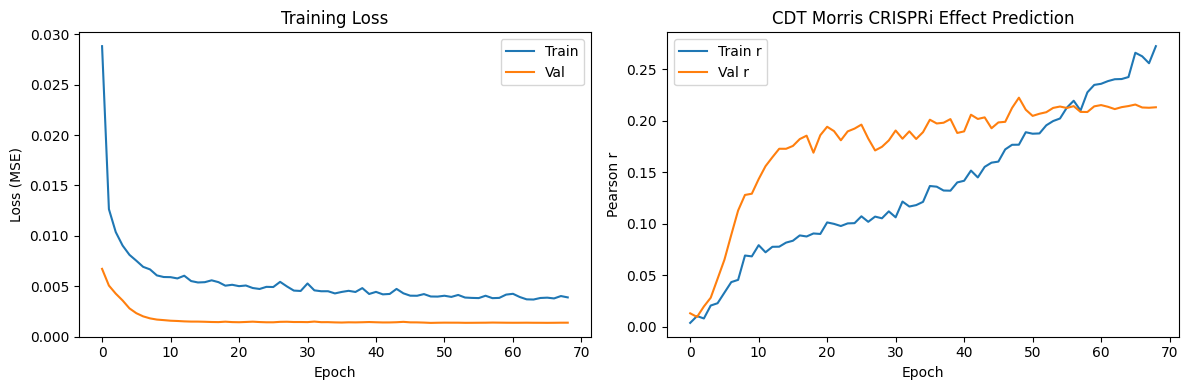


Results saved to /content/drive/MyDrive/cdt_outputs/morris_crispri


In [16]:
import matplotlib.pyplot as plt

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].set_title('Training Loss')

axes[1].plot(history['train_r'], label='Train r')
axes[1].plot(history['val_r'], label='Val r')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Pearson r')
axes[1].legend()
axes[1].set_title('CDT Morris CRISPRi Effect Prediction')

plt.tight_layout()
plt.savefig(OUTPUT_BASE / f"training_history_morris_crispri_{timestamp}.png", dpi=150)
plt.show()

# Save results
results = {
    'version': 'morris_crispri_v1',
    'description': 'CDT v2 Morris CRISPRi Effect Prediction',
    'config': config,
    'best_val_loss': float(best_loss),
    'best_val_r': float(max(history['val_r'])),
    'n_perturbations': len(target_genes),
    'n_train': len(train_dataset),
    'n_val': len(val_dataset),
    'timestamp': timestamp,
}

with open(OUTPUT_BASE / f"results_morris_crispri_{timestamp}.json", 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to {OUTPUT_BASE}")

## Done!

### Summary
- **Task**: Predict CRISPRi perturbation effects on gene expression
- **Model**: CDT v2 (DNA + RNA only, no Protein)
- **Data**: 27 perturbations from Morris STINGseq
- **Output**: log2 fold change on 2,360 genes

### Next Steps
1. Generate Enformer embeddings for 23 genes (run Morris_28genes_Enformer.ipynb first)
2. Upload effects file to Google Drive
3. Train and evaluate
4. If successful, extend to SNP-targeting gRNAs (Phase 2)